## Import data and packages

Our dataset ("healthcare_risk_dataset.csv") is a synthetic dataset from Kaggle. Some major features include Age, Gender, Glucose, BMI, Medical Condition, etc. We'll use a GMM to see if it can find various patterns within the dataset, but without the Medical Condition column. Since this is an unsupervised method, we will remove the Medical Condition column to avoid any pre-categorization of the data and to reduce data leakage.

In [ ]:
# Import kits/packages here
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.cluster import KMeans

In [72]:
# Load dataset
data = pd.read_csv("healthcare_risk_dataset.csv")
print(f"Data shape: {data.shape}")

Data shape: (30000, 20)


## Data Cleaning and Pre-Processing

In [ ]:
# Get information about columns
data.info()

# Retrieve column names
column_names = data.columns.tolist()

# Check for missing values
missing = data.isna().sum()
print(f"\nNumber of missing values: \n{missing}")

# Age, Gender, Medical Condition, Glucose, and Blood Pressure are missing values!
# Since there isn't a significant amount missing, we can impute these missing values



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

In [ ]:
# Create function to handle both missing numerical and categorical values

def impute_columns(df:pd.DataFrame) -> pd.DataFrame:
    """
    Parameters
    ----------
    df : pd.DataFrame
        Pandas dataframe with missing values

    Returns
    -------
    df : pd.DataFrame
        Pandas dataframe with numerical and categorical columns imputed 
    """
    
    # Get column types and save into a list
    numerical_columns = [col for col in df.columns if df[col].dtype in ["float64" or "int64"]]
    categorical_columns = [col for col in df.columns if df[col].dtype == "object"]

    # Impute numerical columns with median
    for col in numerical_columns:
        df[col] = df[col].fillna(df[col].median())

    # Impute categorical columns with mode
    for col in categorical_columns:
        df[col] = df[col].fillna(df[col].mode()[0])

    return df

In [75]:
# First, replace the missing values with NaN
data = data.replace(["NA", "N/A", "na", "n/a", "NaN", "nan", ""], np.nan)

# Impute the missing values
data = impute_columns(data)
print(f"Cleaned data: \n{data.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                30000 non-null  float64
 1   Gender             30000 non-null  object 
 2   Medical Condition  30000 non-null  object 
 3   Glucose            30000 non-null  float64
 4   Blood Pressure     30000 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

In [76]:
# The noise_col and random_notes columns aren't needed, let's drop them
data = data.drop(["random_notes", "noise_col"], axis=1)

# Lastly, let's drop any duplicate rows to be safe
print(f"Dataset shape with duplicates: {data.shape}")
data = data.drop_duplicates().reset_index(drop=True)
print(f"Dataset without duplicates: {data.shape}")

Dataset shape with duplicates: (30000, 18)
Dataset without duplicates: (30000, 18)


In [ ]:
# The "medical condition" column should be removed for this analysis because we want it to act more like a label rather than a feature
# We'll use it for labeling later to see if the unsupervised learning models clustered the data according to them, so let's save it into a new object

medical_condition_copy = data["Medical Condition"] # Keep a copy of the column
cleaned_data = data.drop("Medical Condition", axis=1) # Drop the column in the cleaned dataset so it won't be used in the model's algorithm



## One-Hot Encode Categorical Columns

Since we removed the "Medical Condition" column (temporarily), we only have to encode the "Gender" column now.

In [78]:
# Grab all remaining categorical columns left, just to be safe
cat_columns = [col for col in cleaned_data.columns if cleaned_data[col].dtype == "object"]

# One-hot encode categorical columns
encoded_columns = []

for col in cat_columns:
    # Get one-hot encoded version
    encoded = pd.get_dummies(cleaned_data[col], prefix=col, dtype=int)
    
    # Track column names
    encoded_columns.extend(encoded.columns.tolist())
    
    # Drop original and add encoded
    cleaned_data = cleaned_data.drop(col, axis=1)
    cleaned_data = pd.concat([cleaned_data, encoded], axis=1)

print(f"Cleaned data: ")
print(cleaned_data.head(10))

Cleaned data: 
    Age  Glucose  Blood Pressure    BMI  Oxygen Saturation  LengthOfStay  \
0  46.0   137.04          135.27  28.90              96.04             6   
1  22.0    71.58          113.27  26.29              97.54             2   
2  50.0    95.24          138.32  22.53              90.31             2   
3  57.0   110.50          130.53  38.47              96.60             5   
4  66.0    95.15          178.17  31.12              94.90             4   
5  50.0   107.00          171.80  25.33              95.21             5   
6  80.0   110.50          174.52  29.87              97.96             3   
7  50.0   110.50          136.13  26.37              82.72            19   
8  60.0   110.50          138.32  35.49              98.62             3   
9  13.0    90.60          126.88  29.24              97.96             6   

   Cholesterol  Triglycerides  HbA1c  Smoking  Alcohol  Physical Activity  \
0       231.88         210.56   7.61        0        0              -0.

## Scale Numerical Columns

The remaining columns have very different scales and would benefit from scaling to prevent one feature being more prominent than another.

In [79]:
# Get numeric columns now that the data is clean
num_columns = [col for col in cleaned_data.columns if cleaned_data[col].dtype in ["float64" or "int64"]]

print(f"Before scaling: ")
print(cleaned_data[num_columns].describe())

# Dictionary for means and stds
means = {}
stds = {}

for col in num_columns:
    means[col] = cleaned_data[col].mean()
    stds[col] = cleaned_data[col].std()

    # This is where the standardizing occurs
    cleaned_data[col] = (cleaned_data[col] - means[col]) / stds[col]

print(f"After scaling: ")
print(cleaned_data[num_columns].describe())

Before scaling: 
                Age       Glucose  Blood Pressure           BMI  \
count  30000.000000  30000.000000    30000.000000  30000.000000   
mean      54.674267    121.653852      140.135036     28.476155   
std       14.727541     38.617255       19.447790      5.728804   
min       10.000000     20.320000       74.240000      7.670000   
25%       47.000000     98.860000      127.730000     24.590000   
50%       55.000000    110.500000      138.320000     28.050000   
75%       64.000000    128.870000      150.630000     31.810000   
max       89.000000    318.510000      226.380000     56.850000   

       Oxygen Saturation   Cholesterol  Triglycerides         HbA1c  \
count       30000.000000  30000.000000   30000.000000  30000.000000   
mean           94.954992    213.033891     176.837375      6.294377   
std             3.736202     33.519757      48.812827      1.320269   
min            67.510000     95.730000     -22.480000      3.280000   
25%            93.000000

## Finding the Best GMM

With GMMs, you have to pre-assign the number of components or clusters for the model. The algorithm won't do this step for us so we can start with a random set of numbers and adjust as we go. To prevent overfitting, we can observe different models and evaluate which one performs best and choose k based on the AIC or BIC.

(We'll look at both later for clarity as BIC is better for true number of clusters and AIC is better to prevent overfitting).

In [ ]:
# Make a function to run multiple models using pre-set parameters

def best_GMM_search(X_cleaned:pd.DataFrame, k_values:range, covariance_type="spherical", random_state=42) -> dict:
    """
    Parameters
    ----------
    X_cleaned:pd.DataFrame
        Pandas dataframe with cleaned data,
    k_values:range 
        Range of k values that you want to loop through,
    covariance_type:str 
        The covariance type to be used by GaussianMixture set to "full",
    random_state:int 
        42 for reproducibility

    Returns
    -------
    all_scores : dict
        Dictionary containing the BIC, AIC, and k value from the best model
    """
    
    model_scores = [] # Holds the scores for each model
    bic_scores = [] # Need for BIC graph
    aic_scores = [] # Need for AIC graph

    for k in k_values:
        gmm = GaussianMixture(n_components=k, covariance_type=covariance_type, random_state=random_state)

        # train model
        gmm.fit(X_cleaned)

        # Extract BIC score
        bic = gmm.bic(X_cleaned)
        bic_scores.append(bic)

        # Extract AIC score
        aic = gmm.aic(X_cleaned)
        aic_scores.append(aic)

        # Store BIC and AIC scores in a dictionary and append to model_scores
        scores = {"k_value" : k,
                  "BIC" : bic,
                  "AIC" : aic}
        model_scores.append(scores)

    best_model_search = min(model_scores, key=lambda x: x["BIC"])

    # Return the best model
    best_k = best_model_search["k_value"]

    all_scores = {"BIC": bic_scores, "AIC" : aic_scores, "k_value" : best_k}

    return all_scores

Best k found: 10


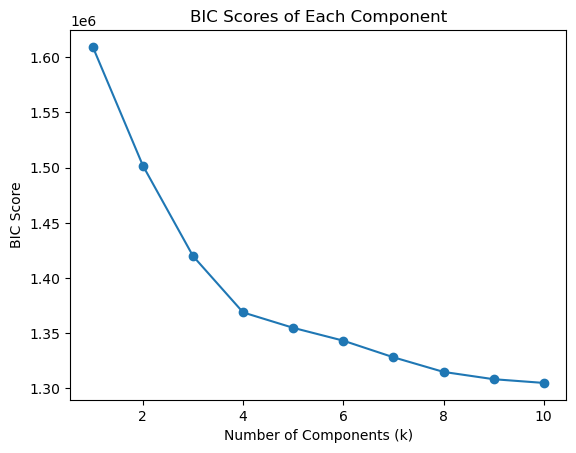

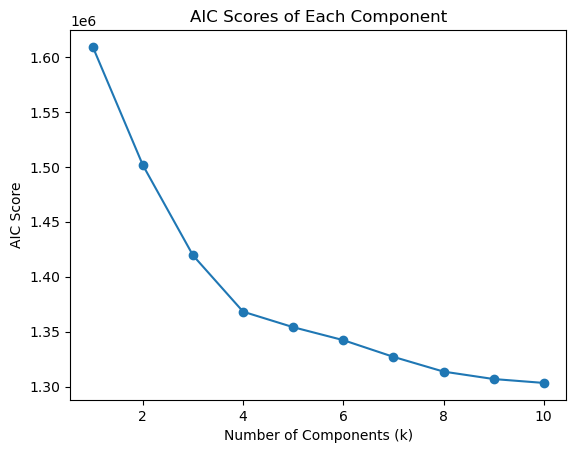

In [81]:
# Create a range of values for the components
k_values = range(1,11)

find_best_k = best_GMM_search(X_cleaned=cleaned_data, k_values=k_values)
print(f"Best k found: {find_best_k["k_value"]}")

# The algorithm thinks 10 clusters is the optimal k, but let's look at the BIC graph and AIC graph to test that
plt.plot(k_values, find_best_k["BIC"], marker="o")
plt.xlabel("Number of Components (k)")
plt.ylabel("BIC Score")
plt.title("BIC Scores of Each Component")
plt.show()

# AIC scores tend to be more flexible with complex models
plt.plot(k_values, find_best_k["AIC"], marker="o")
plt.xlabel("Number of Components (k)")
plt.ylabel("AIC Score")
plt.title("AIC Scores of Each Component")
plt.show()

Despite the lowest BIC value equating to 10 components, we'll actually use 5 as our k. This is because after 5 components, there is a very minimal decrease in BIC score. We could use 10 components but we would risk overfitting, and with a dataset this large, it could make the model more unstable. 

We also went with a "spherical" covariance type because the "full" model BIC scores demonstrated significant instability around 8-10 components, and again, we want to avoid overfitting where possible. 

## Final Gaussian Mixture Model

Use covariance_type = "spherical", n_components = 5.

In [82]:
# Run and fit GMM using the parameters from the best model

final_gmm = GaussianMixture(n_components=5, covariance_type="spherical", random_state=42)
final_gmm.fit(cleaned_data)

# Predict the probabilities and labels for each point
labels = final_gmm.predict(cleaned_data)
probabilities = final_gmm.predict_proba(cleaned_data)

Our dataset has > 2 columns, so it can't be directly plotted onto a figure. We'll need to run a PCA to reduce the dimensionality first.

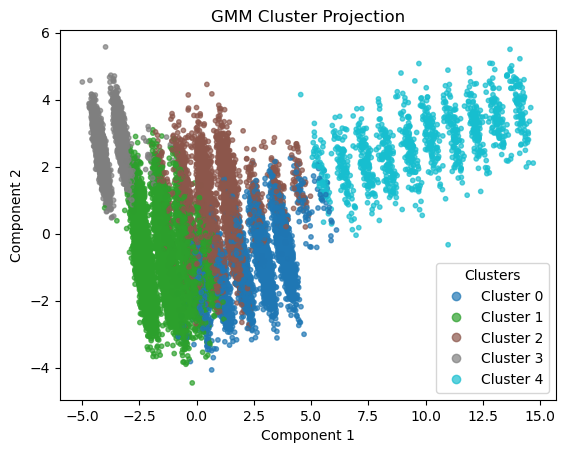

In [95]:
# Run a PCA on the cleaned data
pca = PCA(n_components=2)
fit_transform_pca = pca.fit_transform(cleaned_data)

# Plot the PCA, colour based on the GMM cluster labels
GMM_plot = plt.scatter(fit_transform_pca[:, 0], fit_transform_pca[:, 1], c=labels, s=10, cmap="tab10", alpha=0.7)

handles, _ = GMM_plot.legend_elements()
plt.legend(handles, [f"Cluster {i}" for i in range(len(handles))], title = "Clusters")
plt.title("GMM Cluster Projection")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [84]:
# Retrieve medical condition column from original data
med_condition_label = medical_condition_copy
print(med_condition_label.head())

0        Diabetes
1         Healthy
2          Asthma
3         Obesity
4    Hypertension
Name: Medical Condition, dtype: object


## Interpreting the Probabilities and Labels

The true strength of GMMs over k-means is the soft clustering assignments. Each data point is assignment probabilities based on how likely they are to belong to each cluster. We'll take a look at some of these probabilities now. 

In [85]:
probabilities = pd.DataFrame(probabilities)
print(probabilities.head(10))

              0             1             2              3             4
0  9.597501e-01  6.203087e-03  3.404678e-02   1.142771e-27  7.137303e-21
1  9.414197e-19  2.016642e-07  6.094453e-10   9.999998e-01  3.816085e-44
2  5.235281e-10  9.906592e-01  9.167015e-03   1.737610e-04  7.010995e-39
3  4.048934e-02  7.760244e-01  1.834863e-01   2.423373e-17  7.889983e-25
4  6.268392e-06  5.187219e-01  4.812718e-01   5.439861e-17  1.258518e-29
5  3.178784e-05  1.629192e-02  9.836763e-01   1.458333e-16  6.071491e-25
6  9.971004e-08  9.355511e-01  6.444885e-02   1.683824e-15  2.525085e-34
7  1.118136e-53  2.809739e-77  1.389390e-56  1.131481e-203  1.000000e+00
8  8.121053e-07  9.985288e-01  1.470416e-03   1.145393e-17  9.395010e-36
9  2.059243e-03  7.511390e-03  9.904294e-01   3.937091e-15  2.664078e-18


Above are the probabilities for the first 10 rows in the dataset. Each data point is given a probability for belonging in all five clusters. Each row adds up to 1. The higher the number, the more likely that the data point belongs to that cluster. Of course, the highest probability doesn't guarantee that this is the true label or true cluster for this data point. This is what the model has predicted.

Although these probabilities give us insight on the GMM's algorithm, the dataset is extremely large and we can't effectively draw conclusions about the clusters looking at the numbers alone. This is why we also extracted the labels (i.e., hard assignments) earlier. Other than for visualization, we can use the labels to determine the feature averages for each cluster to help us interpret the results further.

In [86]:
# Add the labels into a copy of the dataset

gmm_clusters = cleaned_data.copy()
gmm_clusters["cluster"] = labels

# Group the data based on their clusters, and then calculate the mean of each column for each row
# Each row will be the clusters, and then we should see the features as the columns

summary = gmm_clusters.groupby("cluster").mean()
print(f"Cluster summaries:\n{summary}")

Cluster summaries:
              Age   Glucose  Blood Pressure       BMI  Oxygen Saturation  \
cluster                                                                    
0        0.137756  1.432609       -0.045961  0.093463           0.014707   
1        0.018557 -0.158338        0.063124  0.367323           0.071508   
2        0.203323 -0.347124        0.433407 -0.261648          -0.332712   
3       -0.669052 -0.637596       -0.881142 -0.796311           0.530417   
4        0.044525 -0.318112       -0.433586 -0.439957          -0.508942   

         LengthOfStay  Cholesterol  Triglycerides     HbA1c   Smoking  \
cluster                                                                 
0            6.492369    -0.095123       0.037411  1.401769  0.207334   
1            3.119347     0.173987       0.215906 -0.082644  0.291814   
2            5.214895     0.251004       0.090576 -0.370740  0.364957   
3            1.513017    -0.997867      -0.961959 -0.830584  0.109071   
4         

Based on the results above, here are some conclusions we can draw about each cluster:

* Cluster 0 has the highest average for glucose level and HbA1c. This group most likely contains data from the patients with diabetes. It also appears that female patients were more likely to be part of this group than the male patients.

* Cluster 1 stands out the most in the BMI feature, with the largest mean. Family history mean is also the third largest, suggesting that this group of individuals or data points likely has a hereditary condition. If we reference the medical condition colouring figure, this cluster likely contains data from individuals with obesity.

* Cluster 2 doesn't have any significant feature standouts, relative to the other clusters. However, this cluster did have the second lowest oxygen saturation, and second highest smoking mean so these individuals might struggle with respiratory issues.

* Cluster 3 likely contains data from the healthy patient group. It has the highest averages in physical activity, sleep hours, and diet score. It also has the lowest averages for smoking, alcohol, and stress.

* Cluster 4 had the highest length of stay, alcohol, smoking, and stress means. If we refer to the figures, we can clearly distinguish cluster 4 from the others. It's also the cluster related to the Cancer label, so maybe this cluster is composed of data from people with poor lifestyle habits too.

### Cluster Sizes

Not all clusters share the same number of data points, so interpretations can be skewed if the distribution is uneven between clusters. Based on the results below, clusters 1 and 2 are significantly more populated than the other 3 clusters.

In [87]:
gmm_clusters["cluster"].value_counts()

cluster
1    13046
2     7157
0     5045
3     3649
4     1103
Name: count, dtype: int64

## K-Means Comparison

Now let's visualize the data using K-means clustering and compare the output to the GMM. For fairness, we'll use the same k (5).

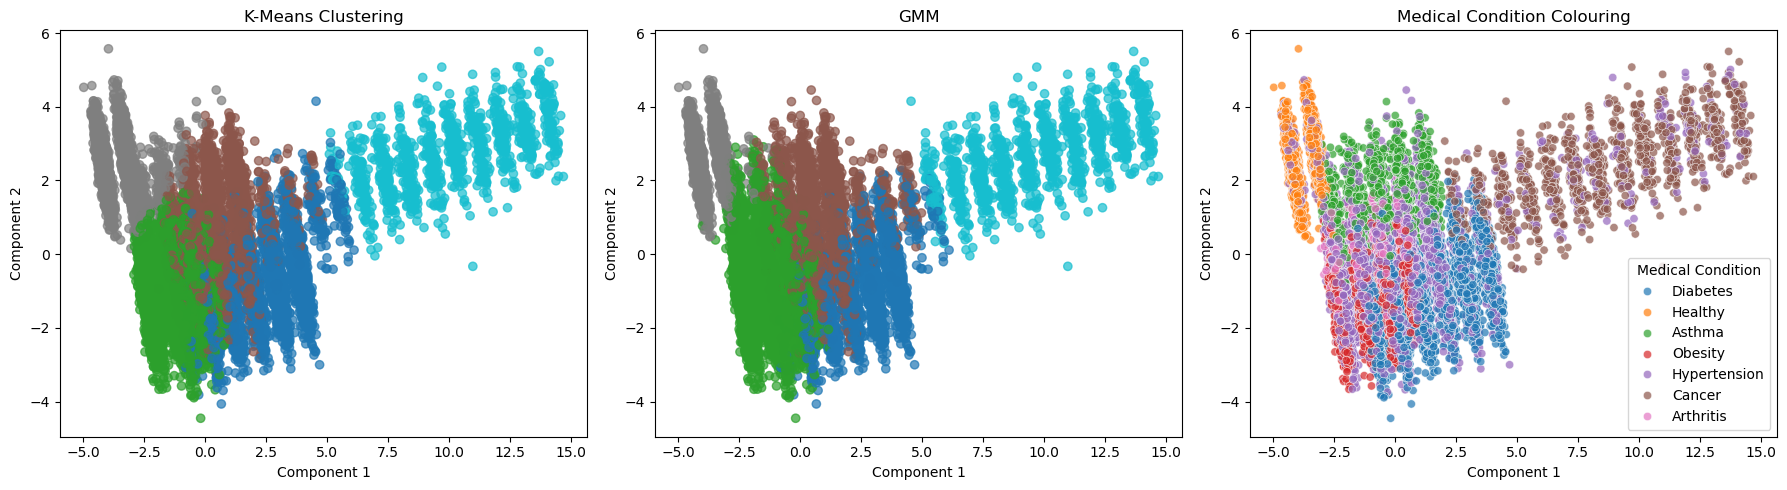

In [ ]:
# Run and fit the K-means model

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit_predict(cleaned_data)

# Retrieve the labels
kmeans_labels = kmeans.labels_
# We can re-use the PCA for dimensionality reduction

fig, axes = plt.subplots(1,3, figsize=(18,5))

# Plot the Kmeans
axes[0].scatter(fit_transform_pca[:,0], fit_transform_pca[:,1], c=kmeans_labels, cmap="tab10", alpha=0.7)
axes[0].set_title("K-Means Clustering")

# Plot the GMM
axes[1].scatter(fit_transform_pca[:,0], fit_transform_pca[:,1], c=labels, cmap="tab10", alpha=0.7)
axes[1].set_title("GMM")

# Plot the GMM with the Medical Condition colouring
sns.scatterplot(x=fit_transform_pca[:,0], y=fit_transform_pca[:,1], hue=med_condition_label, palette="tab10", alpha=0.7, ax=axes[2])
axes[2].set_title("Medical Condition Colouring")

for ax in axes:
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.tight_layout()
plt.show()

Visually, the k-means clustering looks very similar, and this is to be expected because the GMM covariance type was set to spherical. The k-mean algorithm assumes that the data is spherical or circular. 

Let's look into the cluster labels from the k-means model and see if they're similar to the GMM.

In [94]:
# Keep a copy of the cleaned dataset and add a new column using the kmeans labels
kmeans_cluster = cleaned_data.copy()
kmeans_cluster["cluster"] = kmeans_labels

# Group the data based on their clusters, and then calculate the mean of each column for each row
# Each row will be the clusters, and then we should see the features as the columns

kmeans_summary = kmeans_cluster.groupby("cluster").mean()
print(f"K-means cluster summaries:\n{kmeans_summary}")

K-means cluster summaries:
              Age   Glucose  Blood Pressure       BMI  Oxygen Saturation  \
cluster                                                                    
0        0.133796  1.372969       -0.056815  0.078545          -0.002270   
1        0.027353 -0.172536        0.067448  0.469751           0.134721   
2        0.239200 -0.352483        0.448605 -0.237105          -0.293705   
3       -0.726789 -0.620471       -0.862576 -0.789763           0.340154   
4        0.039881 -0.319724       -0.437835 -0.434747          -0.502235   

         LengthOfStay  Cholesterol  Triglycerides     HbA1c   Smoking  \
cluster                                                                 
0            6.399392    -0.097498       0.035186  1.352086  0.215511   
1            3.041839     0.197759       0.274084 -0.075712  0.287295   
2            4.994673     0.274454       0.081757 -0.380689  0.364841   
3            1.642565    -0.940900      -0.903846 -0.807039  0.131396   
4 

As we can see, the feature averages for each cluster is nearly identical to the GMM's results. While we could have used a different covariance type for the GMM to demonstrate how they can fit more complex shapes, the clustering pattern in the k-means model actually suggests that we don't need complex models to capture patterns within the data. In addition, having two models that demonstrate similar clustering provides higher confidence for our results.

Another notable outcome of this analysis is that both the GMM and k-means model can recover the known labels of the data, but up to a certain extent. There's significant overlap to the left of each 2D projection. This can be attributed to two things: the PCA diluting the relationships between every data point, and the likelihood of each data point or patient having overlapping clinical/lifestyle factors. The latter reflects the behaviour of real-life data, where many conditions have similar clinical manifestations.